In [2]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.stats as sms
import statsmodels.api as sm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import altair as alt

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
kc = pd.read_csv('kc_house_data.csv')

In [4]:
kc.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [5]:
kc['date'] = pd.to_datetime(kc.date)

In [6]:
sqft_to_sqmeters = 0.09290303997

In [7]:
kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float})

In [8]:
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

In [9]:
kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

In [10]:
kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

In [11]:
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan
kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan

In [13]:
alt.data_transformers.disable_max_rows()
alt.renderers.enable('default')

RendererRegistry.enable('default')

In [14]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=50, r=0, t=20, b=50),
    xaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    colorscale=dict(
        sequential=px.colors.sequential.Inferno
    ),
    colorway=px.colors.qualitative.T10
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

Exploratory data analysis

In [405]:
kc.id.value_counts().value_counts()

count
1    21260
2      175
3        1
Name: count, dtype: int64

In [15]:
px.histogram(kc, 'date', height=400
).update_traces(xbins_start=kc.date.min(),
                xbins_end=kc.date.max(),
                xbins_size='D',
                marker_cornerradius=20
).update_xaxes(dtick=7*24*60*60*1000,
               minor_dtick=24*60*60*1000,
               minor_showgrid=True,
               tickangle=-65,
               ticks='outside',
               tick0='2014-05-05'
).update_layout(margin=dict(b=70))

In [17]:
px.histogram(kc, x='price', height=200
).update_traces(
    xbins_size=10**4,
    marker_cornerradius=10
)

In [18]:
px.histogram(kc, x='price', height=200, log_x=True
).update_traces(
    xbins_size=10**4,
    marker_cornerradius=10
)

In [19]:
pd.DataFrame(kc.floors.value_counts()).T

floors,1.0,2.0,1.5,3.0,2.5,3.5
count,10680,8241,1910,613,161,8


In [20]:
pd.DataFrame(kc.bedrooms.value_counts()).T

bedrooms,3,4,2,5,6,1,7,0,8,9,10,11,33
count,9824,6882,2760,1601,272,199,38,13,13,6,3,1,1


In [21]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,:15]

bathrooms,2.50,1.00,1.75,2.25,2.00,1.50,2.75,3.00,3.50,3.25,3.75,4.00,4.50,4.25,0.75
count,5380,3852,3048,2047,1930,1446,1185,753,731,589,155,136,100,79,72


In [22]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,15:]

bathrooms,4.75,5.00,5.25,0.00,5.50,1.25,6.00,0.50,5.75,6.75,8.00,6.50,6.25,7.75,7.50
count,23,21,13,10,10,9,6,4,4,2,2,2,2,1,1


In [23]:
kc[['waterfront', 'view', 'condition', 'grade']].apply(lambda x: x.value_counts()).T.fillna('')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
waterfront,21450.0,163.0,,,,,,,,,,,,
view,19489.0,332.0,963.0,510.0,319.0,,,,,,,,,
condition,,30.0,172.0,14031.0,5679.0,1701.0,,,,,,,,
grade,,1.0,,3.0,29.0,242.0,2038.0,8981.0,6068.0,2615.0,1134.0,399.0,90.0,13.0


Text(0.5, 0, 'square meters')

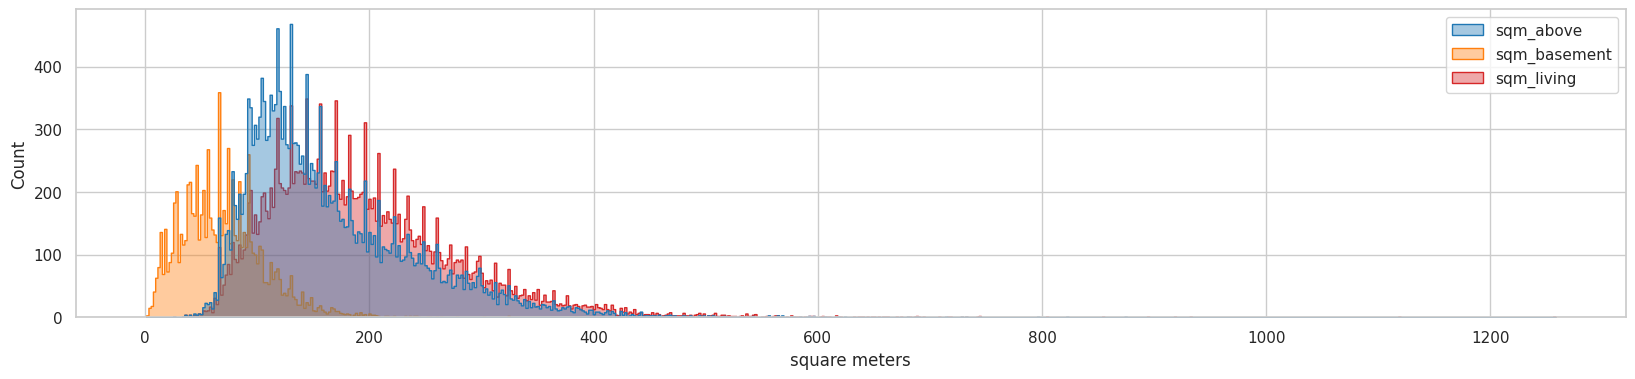

In [24]:
sns.set(rc={"figure.figsize":(20,4)})
sns.set_style('whitegrid')
sns.histplot(kc[['sqm_above', 'sqm_basement', 'sqm_living']],
             binwidth=2, palette=['#1f77b4', '#ff7f0e', '#d62728'],
             multiple='layer', element='step', alpha=0.4, linewidth=1)
plt.xlabel('square meters')

Text(0.5, 0, 'square meters')

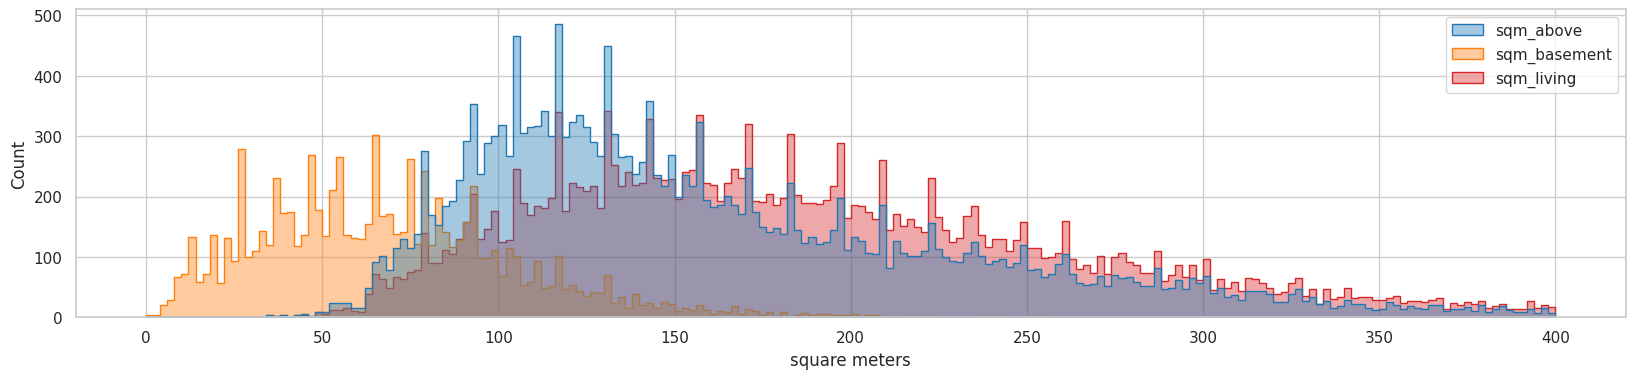

In [25]:
sns.set(rc={"figure.figsize":(20,4)})
sns.set_style('whitegrid')
sns.histplot(kc[['sqm_above', 'sqm_basement', 'sqm_living']],
             palette=['#1f77b4', '#ff7f0e', '#d62728'],
             binrange=(0,400), binwidth=2, multiple='layer', element='step', 
             alpha=0.4, linewidth=1)
plt.xlabel('square meters')

In [26]:
px.histogram(kc, x='sqm_lot', height=200, log_x=True
).update_traces(xbins_size=16, marker_cornerradius=10)

In [27]:
kc.id.count()

np.int64(21613)

In [28]:
kc.loc[kc.sqm_living==kc.sqm_above,'sqm_above'].count()

np.int64(13126)

In [29]:
kc.loc[kc.sqm_above==kc.sqm_basement,'sqm_basement'].count()

np.int64(551)

In [30]:
kc.sqm_basement.isna().sum()

np.int64(13126)

In [31]:
(kc.sqm_basement.isna() == np.where(kc.sqm_living==kc.sqm_above, 1, 0)).sum()

np.int64(21613)

Text(0.5, 0, 'year built')

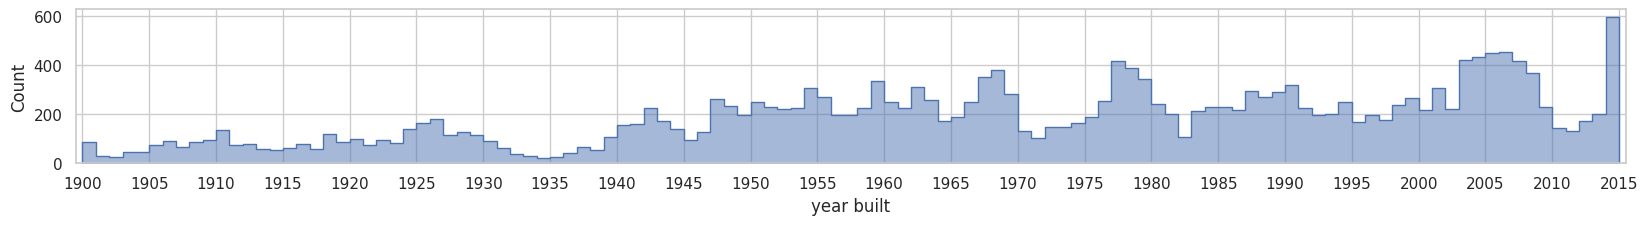

In [32]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_built, binrange=(1900,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=40)
plt.xlim(1899.5,2015.5)
plt.xlabel('year built')

Text(0.5, 0, 'year of renovation')

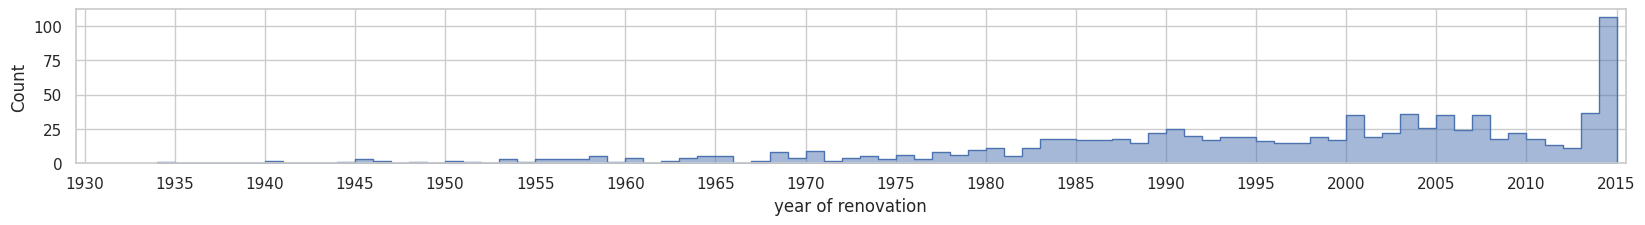

In [33]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_renovated, binrange=(1934,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=30)
plt.xlim(1929.5,2015.5)
plt.xlabel('year of renovation')

In [49]:
kc.yr_renovated.notna().sum()

np.int64(914)

In [36]:
# px.scatter_map(kc, lat='lat', lon='long', size='sqm_living', size_max=10, zoom=9, template='plotly_dark',
#                color='price', map_style='carto-darkmatter', color_continuous_scale='plasma'
#                ).update_layout(margin=dict(l=0,r=0,b=0,t=0)
#                ).show(renderer='png', width=1500, height=500)

##### Regressions

In [38]:
# alt.Chart(kc).mark_circle(
#     size=20, opacity=0.75, tooltip=True
# ).encode(
#     alt.X(alt.repeat("column"), type='quantitative').scale(zero=False).axis(format='~s'),
#     alt.Y(alt.repeat("row"), type='quantitative').scale(zero=False).axis(format='~s'),
#     alt.Color('condition:N').scale(scheme='tableau10')
# ).properties(
#     width=200,
#     height=200
# ).repeat(
#     row=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built', 'yr_renovated'],
#     column=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built', 'yr_renovated']
# ).configure_facet(spacing=0
# ).configure_legend(symbolOpacity=1)

In [39]:
###### Regression assumptions:
######
###### 1) Linearity - residual plot (against predicted values Y^)
######    - change reg. model, transform predictors
###### 2) Homoscedasticity -> risk of small p-values (type I error) - residual plot
######    - use Poisson regression (if counts) or weighted least squares regression
######    - transform the data
######    - use robust standard errors (of coefficients) - it transforms p-values
###### 3) Normality - kdeplot/histogram or QQplot, for residuals, Jarque-Bera
######    - add expl. variable
######    - transform data / change model
######    - remove outliers - Cook's distance ( threshold = 4 / (n - k - 1) )
###### 4) Independence (no autocorelation)
######    = if timeseries, check residuals vs time variable - transform the data
######    = Durbin-Watson (must be between 2 and 3)
###### 5) No colinearity - large condition number, Variance inflation factor (VIF) >5 
######                   -> inflated p-values, wide confidence intervals
######    - remove or combine variables (ex height and weight into bmi)
######    - principal component regression
######    - partial least squares regression

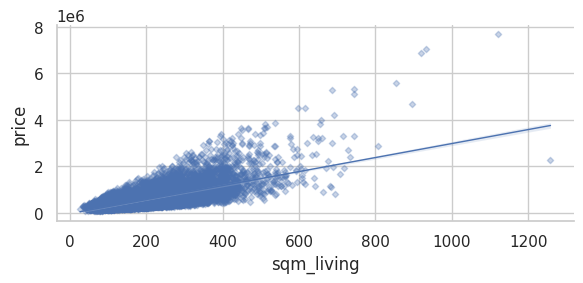

In [42]:
sns.set_style('whitegrid')
sns.lmplot(kc, x='sqm_living', y='price', # hue='waterfront',
           aspect=2, height=3, markers='D',
           scatter_kws={'s': 10, 'alpha':0.3}, line_kws={'linewidth':1})

In [409]:
px.scatter(kc, x=np.log10(kc.sqm_living),
           y=np.log10(kc.price), 
           color=kc.grade, #kc.grade.astype('str'),
           trendline='ols', trendline_scope='overall',
           opacity=0.7, width=1000, height=300
           ).update_traces(marker_size=5)

In [44]:
kc_log = kc.copy()
kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']] = \
np.log10(kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']])

In [84]:
kc_log.loc[:,'sqm_basement'] = kc_log.loc[:,'sqm_basement'].fillna(0)
kc_log.yr_renovated.fillna(kc.yr_built, inplace=True)

In [ ]:
# facets = []
# features = ['sqm_living', 'sqm_above', 'sqm_basement', 'sqm_lot', 'sqm_living15', 'sqm_lot15']
# color = 'condition'

# for feature1 in features:
#     for feature2 in features:
#         if feature1 == feature2:
#             chart = alt.Chart(kc_log).mark_area(
#                 tooltip=True, line=False, opacity=0.5, interpolate='step-after'
#                 ).encode(
#                 x=alt.X(f"{feature1}:Q").bin(step=0.01, nice=False).axis(format='~s').stack(None),
#                 y=alt.Y("count()").axis(format='~s'),
#                 color=alt.Color(f"{color}:N")
#             )
#         else:
#             chart = alt.Chart(kc_log).mark_circle(tooltip=True).encode(
#                 x=alt.X(f"{feature2}:Q").axis(format='~s'),
#                 y=alt.Y(f"{feature1}:Q").axis(format='~s'),
#                 color=alt.Color(f"{color}:N")
#             )
#         facets.append(chart)

# figure = alt.vconcat(*[alt.hconcat(*facets[i:i+len(features)]) for i in range(0, len(facets), len(features))])
# figure = figure.properties(title="Pairplot")
# figure.configure_legend(symbolOpacity=1)

In [222]:
design_df = kc_log.drop(columns=['id', 'date', 'price', 'lat', 'long']).copy()
design_df = sm.add_constant(design_df)
for i in range(0, len(design_df.columns)):
    print(i, design_df.columns[i], '        ', variance_inflation_factor(design_df,i))

0 const          9642.030010469265
1 floors          2.3898753285218115
2 bedrooms          1.7763680799232415
3 bathrooms          3.3460206534842585
4 yr_built          6.049102618389534
5 yr_renovated          6.429145061014953
6 waterfront          1.2033801627943619
7 view          1.375485164055538
8 condition          1.2417716302704556
9 grade          3.054960838139965
10 sqm_living          33.05388138659022
11 sqm_lot          6.880042660177272
12 sqm_above          31.80768575030853
13 sqm_basement          8.297376947844382
14 sqm_living15          2.7720199425368244
15 sqm_lot15          6.651774763629841


In [223]:
design_df = kc_log.drop(columns=['id', 'date', 'price', 'yr_renovated',
                                'sqm_above', 'sqm_basement',
                                'sqm_living15', 'sqm_lot15',
                                'lat', 'long']).copy()
design_df = sm.add_constant(design_df)
for i in range(0, len(design_df.columns)):
    print(i, design_df.columns[i], '        ', variance_inflation_factor(design_df,i))

0 const          8104.094163659801
1 floors          1.788597380970194
2 bedrooms          1.7635533677447477
3 bathrooms          3.1635234271414383
4 yr_built          1.7478901903076154
5 waterfront          1.1987279723740194
6 view          1.3323592392890007
7 condition          1.1854759616976698
8 grade          2.734358660800345
9 sqm_living          4.535877024814968
10 sqm_lot          1.3680995059706051


In [324]:
# design_df=kc_log.drop(columns=['id','date','price','lat','long']).copy()
# design_df = sm.add_constant(design_df)
# r2_all = sm.OLS(endog=kc_log.price, exog=design_df).fit().rsquared
# dropped, r2, r2_diff, mse, f_value, f_p_value, aic, bic, llk = [[]] * 9
# for col in design_df.columns[1:]:
#     m_test_r2 = sm.OLS(endog=kc_log.price, exog=design_df.drop(columns=col)).fit()
#     dropped = dropped + [col]
#     r2 = r2 + [m_test_r2.rsquared]
#     r2_diff = r2_diff + [r2_all - m_test_r2.rsquared]
#     mse = mse + [m_test_r2.scale]
#     f_value = f_value + [m_test_r2.fvalue]
#     f_p_value = f_p_value + [m_test_r2.f_pvalue]
#     aic = aic + [m_test_r2.aic]
#     bic = bic + [m_test_r2.bic]
#     llk = llk + [m_test_r2.llf]
# pd.DataFrame({'dropped':dropped, 'R^2':r2, 'R^2 diff':r2_diff,
#               'MSE':mse, 'F':f_value, 'F_p':f_p_value,
#               'aic':aic,'bic':bic,'Log-Likelihood':llk}).sort_values(by='R^2')

In [327]:
selected, r2, mse, f_value, f_p_value, aic, bic, llk = [[]] * 8
for col in kc_log.drop(columns=['id','date','price','lat','long']).columns:
    design_df = sm.add_constant(kc_log[col])
    m_test_r2 = sm.OLS(endog=kc_log.price, exog=design_df).fit()
    selected = selected + [col]
    r2 = r2 + [m_test_r2.rsquared]
    mse = mse + [m_test_r2.scale]
    f_value = f_value + [m_test_r2.fvalue]
    f_p_value = f_p_value + [m_test_r2.f_pvalue]
    aic = aic + [m_test_r2.aic]
    bic = bic + [m_test_r2.bic]
    llk = llk + [m_test_r2.llf]
pd.DataFrame({'predictor':selected,'R^2':r2,'MSE':mse,
              'F':f_value, 'F_p':f_p_value,
              'aic':aic,'bic':bic,'Log-Likelihood':llk}).sort_values(by='R^2', ascending=False)

,predictor,R^2,MSE,F,F_p,aic,bic,Log-Likelihood
8,grade,0.495101,0.026418,21191.618256,0.000000e+00,-17198.608314,-17182.646214,8601.304157
9,sqm_living,0.455507,0.028489,18079.138446,0.000000e+00,-15566.902028,-15550.939928,7785.451014
13,sqm_living15,0.368677,0.033033,12620.266010,0.000000e+00,-12368.970843,-12353.008742,6186.485421
11,sqm_above,0.343751,0.034337,11320.082445,0.000000e+00,-11532.062092,-11516.099991,5768.031046
2,bathrooms,0.303383,0.036449,9411.775214,0.000000e+00,-10241.866538,-10225.904437,5122.933269
6,view,0.120077,0.046040,2949.116134,0.000000e+00,-5193.117563,-5177.155463,2598.558782
1,bedrooms,0.118034,0.046147,2892.219357,0.000000e+00,-5142.990087,-5127.027986,2573.495043
0,floors,0.096446,0.047276,2306.782639,0.000000e+00,-4620.338350,-4604.376250,2312.169175
12,sqm_basement,0.061753,0.049092,1422.369896,1.638434e-301,-3805.999495,-3790.037394,1904.999747
5,waterfront,0.030480,0.050728,679.420086,1.695901e-147,-3097.373289,-3081.411188,1550.686644


In [281]:
kc_z=kc_log.copy()
for col in kc_z.drop(columns=['id', 'date', 'lat', 'long']).columns:
    kc_z.loc[:,col] = st.zscore(kc_z.loc[:,col])

In [235]:
m_stadardised = smf.ols('price ~ floors + bedrooms + bathrooms + yr_built + waterfront + view + condition + grade + sqm_living + sqm_lot', data=kc_z)

In [430]:
m_stadardised.fit().params.round(5).abs().sort_values(ascending=False)

grade         0.50886
sqm_living    0.34304
yr_built      0.31729
bathrooms     0.11194
view          0.08239
sqm_lot       0.07376
bedrooms      0.06293
waterfront    0.05976
floors        0.05209
condition     0.04516
Intercept     0.00000
dtype: float64

In [254]:
m_stadardised.fit(cov_type='HC1').summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
===================================================================
Model:              OLS              Adj. R-squared:     0.651     
Dependent Variable: price            AIC:                38617.6760
Date:               2025-09-26 18:21 BIC:                38705.4676
No. Observations:   21613            Log-Likelihood:     -19298.   
Df Model:           10               F-statistic:        3383.     
Df Residuals:       21602            Prob (F-statistic): 0.00      
R-squared:          0.651            Scale:              0.34938   
--------------------------------------------------------------------
                Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
--------------------------------------------------------------------
Intercept      -0.0000    0.0040   -0.0000  1.0000  -0.0079   0.0079
floors          0.0521    0.0054    9.6617  0.0000   0.0415   0.0627
bedrooms       -0.0629    0.0090   -7.0071  0.0000  -0.0805  -0.0453
bathrooms       0.1119    0.0077   14.5739  0.0000   0.0969   0.1270
yr_built       -0.3173    0.0053  -59.4142  0.0000  -0.3278  -0.3068
waterfront      0.0598    0.0051   11.7077  0.0000   0.0498   0.0698
view            0.0824    0.0047   17.5715  0.0000   0.0732   0.0916
condition       0.0452    0.0046    9.7230  0.0000   0.0361   0.0543
grade           0.5089    0.0070   72.9113  0.0000   0.4952   0.5225
sqm_living      0.3430    0.0101   33.8902  0.0000   0.3232   0.3629
sqm_lot        -0.0738    0.0049  -14.9833  0.0000  -0.0834  -0.0641
-------------------------------------------------------------------
Omnibus:               76.690       Durbin-Watson:          1.964  
Prob(Omnibus):         0.000        Jarque-Bera (JB):       100.300
Skew:                  -0.039       Prob(JB):               0.000  
Kurtosis:              3.324        Condition No.:          5      
===================================================================
Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

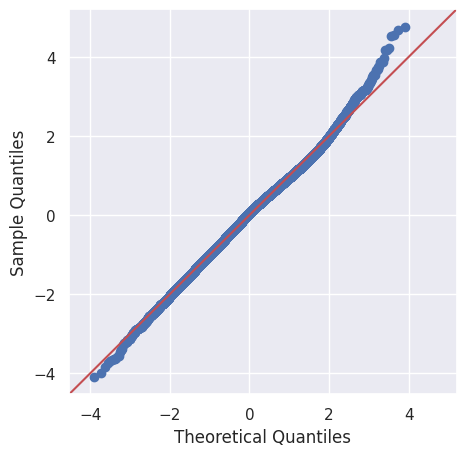

In [239]:
sns.set(rc={"figure.figsize":(5,5)})
sm.qqplot(data = m_stadardised.fit().resid,
          line ='45', fit=True)
plt.show()

In [240]:
px.scatter(data_frame=kc_z, x=m_stadardised.fit().fittedvalues, y=m_stadardised.fit().resid, trendline='ols',trendline_color_override='black')

In [399]:
px.imshow(kc.loc[:,'price':].corr(), width=1000, height=1000,
          color_continuous_scale=px.colors.diverging.curl_r,
          color_continuous_midpoint=0
).update_layout(margin=dict(l=100)).update_xaxes(side='top')